# Step 1: Import Libraries & Load Data
Import the necessary libraries and load the raw data from the `data/raw` directory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ydata_profiling import ProfileReport
import os

# Set the plotting style
sns.set_theme(style="whitegrid")

# Load the raw dataset (Note the relative path: Notebook is in notebooks/, data is in data/raw/)
file_path = '../data/raw/diabetes_012_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

print(f"Dataset loaded successfully! Shape of the data: {df.shape}")

/Users/xiangyitao/Desktop/summer26-diabetes-prediction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset loaded successfully! Shape of the data: (253680, 22)


/var/folders/3d/7b9r8jkn65dg832jd6xrm5480000gn/T/ipykernel_7624/2661979161.py:6: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


# Step 2: High-Level Overview
Perform an initial inspection of the dataset, including data types, null values, and basic statistics.

In [2]:
# Display the first 5 rows
display(df.head())

# Check data types and non-null counts
print("\n--- Data Info ---")
df.info()

# View basic statistical metrics (mean, std, min, max, etc.)
display(df.describe())



,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


# Step 3: Data Cleaning
Handle missing values and duplicates.
*Note: Since the BRFSS dataset relies on survey responses and consists mostly of 0/1 binary questions, having identical rows (two respondents providing the exact same answers to all questions) is highly probable. Removing duplicates should be done cautiously based on project assumptions. The code below demonstrates how to check for them.*

In [3]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("Great! No missing values found.")

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")


df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")


Missing values in each column:
 Series([], dtype: int64)
Great! No missing values found.

Number of duplicate rows: 23899
Shape after removing duplicates: (229781, 22)


# Step 4: Exploratory Data Analysis (EDA)
## 4.1 Target Variable Distribution
Examine the class distribution of `Diabetes_012`. 
* 0: No Diabetes
* 1: Prediabetes
* 2: Diabetes

/var/folders/3d/7b9r8jkn65dg832jd6xrm5480000gn/T/ipykernel_7624/3425176199.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Diabetes_012', palette='viridis')


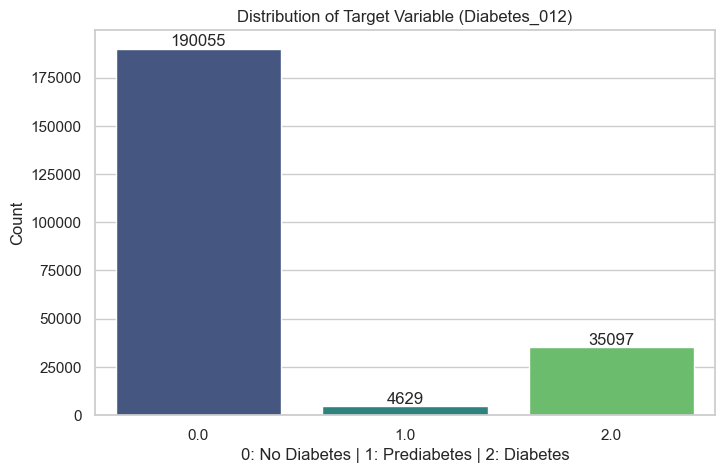

In [4]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Diabetes_012', palette='viridis')
plt.title('Distribution of Target Variable (Diabetes_012)')
plt.xlabel('0: No Diabetes | 1: Prediabetes | 2: Diabetes')
plt.ylabel('Count')

# Add exact count annotations on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

## 4.2 Correlation Analysis
Visualize the correlation between features and the target variable using a heatmap to identify strong predictors and potential multicollinearity.

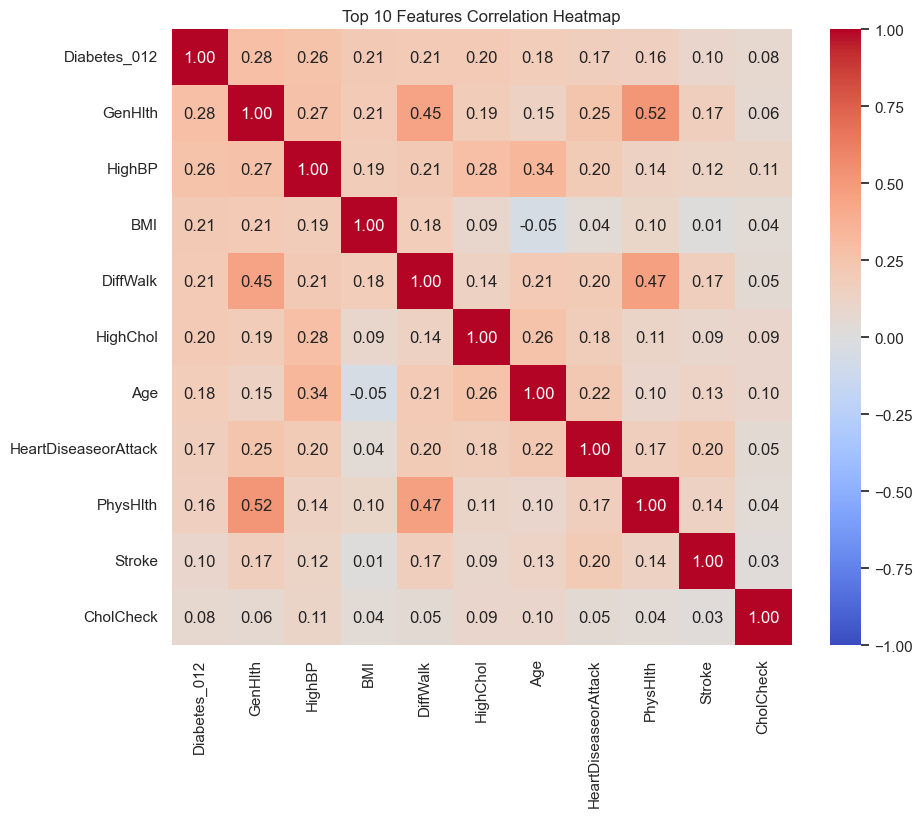

In [5]:
# Calculate the correlation matrix
corr_matrix = df.corr()

# Extract the top 10 features most highly correlated with the target variable
top_corr_features = corr_matrix.nlargest(11, 'Diabetes_012')['Diabetes_012'].index

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Top 10 Features Correlation Heatmap')
plt.show()

## 4.3 Automated Exploratory Data Analysis
Generate a comprehensive HTML profiling report using `sweetviz` and `dtale`. 
*Note: Generating this report on the full 250k+ row dataset can be memory-intensive. We will save it directly to an external HTML file rather than displaying it inline to prevent the notebook from crashing.*

In [6]:
profile = ProfileReport(df, title="Diabetes Dataset EDA Report", explorative=True)

# Ensure the output directory exists
reports_dir = '../reports/'
os.makedirs(reports_dir, exist_ok=True)

# Save the report to an HTML file instead of displaying it inline
report_path = os.path.join(reports_dir, 'diabetes_automated_eda_report.html')
profile.to_file(report_path)

print(f"Success! The automated EDA report has been saved to: {report_path}")
print("Please open this HTML file in your web browser to view the full interactive report.")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 235.69it/s]

Success! The automated EDA report has been saved to: ../reports/diabetes_automated_eda_report.html
Please open this HTML file in your web browser to view the full interactive report.


# Step 5: Preliminary Feature Engineering
Based on the EDA results, perform initial data transformations. Since most of the BRFSS dataset consists of pre-processed 0/1 categorical variables, we primarily ensure correct data types and observe the distribution of continuous variables (like BMI) in preparation for modeling.

/var/folders/3d/7b9r8jkn65dg832jd6xrm5480000gn/T/ipykernel_7624/769508385.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diabetes_012', y='BMI', data=df, palette='Set2')


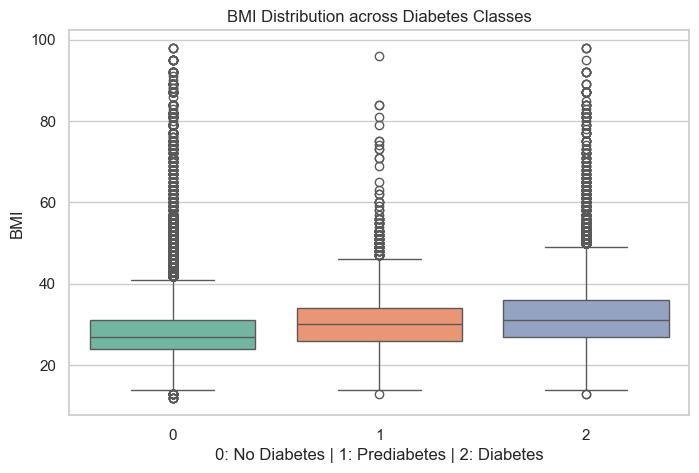

In [7]:
# Most columns are floats (0.0, 1.0), we can convert them to integers to save memory and speed up processing
float_cols = df.select_dtypes(include=['float64']).columns
df[float_cols] = df[float_cols].astype('int64')

# Observe the distribution of BMI across different diabetes classes to check for outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x='Diabetes_012', y='BMI', data=df, palette='Set2')
plt.title('BMI Distribution across Diabetes Classes')
plt.xlabel('0: No Diabetes | 1: Prediabetes | 2: Diabetes')
plt.show()